# INFOF422 project report
### Authors: Group 42 - Pacôme van Overschelde & Bilal Kostet

## Introduction
The goal of this project is to blablabla

## Data Preprocessing 

In [14]:
library(ggplot2)
library(GGally)
library(skimr)
library(dplyr)
library(randomForest)

Warning message:
"le package 'dplyr' a été compilé avec la version R 4.2.3"

Attachement du package : 'dplyr'


Les objets suivants sont masqués depuis 'package:stats':

    filter, lag


Les objets suivants sont masqués depuis 'package:base':

    intersect, setdiff, setequal, union




## Data cleaning

Let us first import our dataset into dataframes. We have three files, one containing training values, one containing training labels (the target), and one containing the test values to be tried in DrivenData. Let us check their content.

In [1]:
train_values <- read.csv("train_values.csv",stringsAsFactors = T)
train_labels <- read.csv("train_labels.csv",stringsAsFactors = T)
test <- read.csv("test_values.csv",stringsAsFactors = T)

In [4]:
dim(train_values)
dim(train_labels)
head(train_values,3)
head(train_labels,3)

[1] 260601     39

[1] 260601      2

,building_id,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,land_surface_condition,foundation_type,⋯,has_secondary_use_agriculture,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other
,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<fct>,<fct>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,802906,6,487,12198,2,30,6,5,t,r,⋯,0,0,0,0,0,0,0,0,0,0
2,28830,8,900,2812,2,10,8,7,o,r,⋯,0,0,0,0,0,0,0,0,0,0
3,94947,21,363,8973,2,10,5,5,t,r,⋯,0,0,0,0,0,0,0,0,0,0


,building_id,damage_grade
,<int>,<int>
1,802906,3
2,28830,2
3,94947,3


Both training files contain the same identifier: building_id. We merge them using this value to match corresponding lines of the files. 

In [5]:
data <- merge(train_values,train_labels,by=c('building_id','building_id'),all.x=T)

We will now check if there are any errors in our dataset. First, we control for NAs and empty cells.

In [7]:
any(is.na(data))
any(data[,]==" ")
any(data[,]=="")

[1] FALSE

[1] FALSE

[1] FALSE

There is no missing data. We also check if there are any duplicates in the building ids.

In [9]:
any(duplicated(data[,1]))

[1] FALSE

Let us now delve into the dataset to see what are our features and if we could identify any possible issues.

In [10]:
summary(data)

  building_id      geo_level_1_id geo_level_2_id   geo_level_3_id 
 Min.   :      4   Min.   : 0.0   Min.   :   0.0   Min.   :    0  
 1st Qu.: 261190   1st Qu.: 7.0   1st Qu.: 350.0   1st Qu.: 3073  
 Median : 525757   Median :12.0   Median : 702.0   Median : 6270  
 Mean   : 525676   Mean   :13.9   Mean   : 701.1   Mean   : 6258  
 3rd Qu.: 789762   3rd Qu.:21.0   3rd Qu.:1050.0   3rd Qu.: 9412  
 Max.   :1052934   Max.   :30.0   Max.   :1427.0   Max.   :12567  
                                                                  
 count_floors_pre_eq      age         area_percentage   height_percentage
 Min.   :1.00        Min.   :  0.00   Min.   :  1.000   Min.   : 2.000   
 1st Qu.:2.00        1st Qu.: 10.00   1st Qu.:  5.000   1st Qu.: 4.000   
 Median :2.00        Median : 15.00   Median :  7.000   Median : 5.000   
 Mean   :2.13        Mean   : 26.54   Mean   :  8.018   Mean   : 5.434   
 3rd Qu.:2.00        3rd Qu.: 30.00   3rd Qu.:  9.000   3rd Qu.: 6.000   
 Max.   :9.00       

The features geo_level_1,2,3_id represent zones of increasing range. We can check if there is any discrepancy in them. Indeed, two buildings in the same geo_level_id_3 should correspond to the same geo_level_id_2, and so on. *Check for secondary use?*

In [17]:
mean_level_1 <- data[,2:4] %>% group_by(geo_level_3_id) %>% 
summarize(across(everything(),list(n_distinct)),)
filter(mean_level_1,geo_level_1_id_1 > 1)
filter(mean_level_1,geo_level_2_id_1 > 1)

geo_level_3_id,geo_level_1_id_1,geo_level_2_id_1
<int>,<int>,<int>


geo_level_3_id,geo_level_1_id_1,geo_level_2_id_1
<int>,<int>,<int>


## Data visualization and exploration

The skim function from the package skimr allows us to have a quick wide view of our data.

In [20]:
skimr::skim(data)

── Data Summary ────────────────────────
                           Values
Name                       data  
Number of rows             260601
Number of columns          40    
_______________________          
Column type frequency:           
  factor                   8     
  numeric                  32    
________________________         
Group variables            None  

── Variable type: factor ───────────────────────────────────────────────────────
  skim_variable          n_missing complete_rate ordered n_unique
1 land_surface_condition         0             1 FALSE          3
2 foundation_type                0             1 FALSE          5
3 roof_type                      0             1 FALSE          3
4 ground_floor_type              0             1 FALSE          5
5 other_floor_type               0             1 FALSE          4
6 position                       0             1 FALSE          4
7 plan_configuration             0             1 FALSE         10
8 legal_o

Warning message in is.null(text_repr) || nchar(text_repr) == 0L:
"‘length(x) = 15 > 1’ dans la conversion automatique vers ‘logical(1)’"


,skim_type,skim_variable,n_missing,complete_rate,factor.ordered,factor.n_unique,factor.top_counts,numeric.mean,numeric.sd,numeric.p0,numeric.p25,numeric.p50,numeric.p75,numeric.p100,numeric.hist
,<chr>,<chr>,<int>,<dbl>,<lgl>,<int>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,factor,land_surface_condition,0,1,FALSE,3,"t: 216757, n: 35528, o: 8316",NA,NA,NA,NA,NA,NA,NA,NA
2,factor,foundation_type,0,1,FALSE,5,"r: 219196, w: 15118, u: 14260, i: 10579",NA,NA,NA,NA,NA,NA,NA,NA
3,factor,roof_type,0,1,FALSE,3,"n: 182842, q: 61576, x: 16183",NA,NA,NA,NA,NA,NA,NA,NA
4,factor,ground_floor_type,0,1,FALSE,5,"f: 209619, x: 24877, v: 24593, z: 1004",NA,NA,NA,NA,NA,NA,NA,NA
5,factor,other_floor_type,0,1,FALSE,4,"q: 165282, x: 43448, j: 39843, s: 12028",NA,NA,NA,NA,NA,NA,NA,NA
6,factor,position,0,1,FALSE,4,"s: 202090, t: 42896, j: 13282, o: 2333",NA,NA,NA,NA,NA,NA,NA,NA
7,factor,plan_configuration,0,1,FALSE,10,"d: 250072, q: 5692, u: 3649, s: 346",NA,NA,NA,NA,NA,NA,NA,NA
8,factor,legal_ownership_status,0,1,FALSE,4,"v: 250939, a: 5512, w: 2677, r: 1473",NA,NA,NA,NA,NA,NA,NA,NA
9,numeric,building_id,0,1,NA,NA,NA,5.256755e+05,3.045450e+05,4,261190,525757,789762,1052934,▇▇▇▇▇


Let us comment some interesting points we can notice in this data.
* There are 40 columns, removing the target it amounts to 39 features to be considered.
* 8 of these features are categorical, while the rest is numeric. Among those numeric features, most of them are binary values. Some other are actually numeric categories: the histograms of building_id, geo_level_1,2,3_id confirms this. They seem to be histograms with almost uniform distributions, meaning that there are a similar amount of building in each zone. This is confirmed in the "Geographical zones distribution" histogram below for the second and third type of zones, but less for the first one.
* Most of the binary features are almost entirely imbalaced towards zero. This also means that our data is sparse. 
* Our target value, damage_grade, seems to be imbalanced.

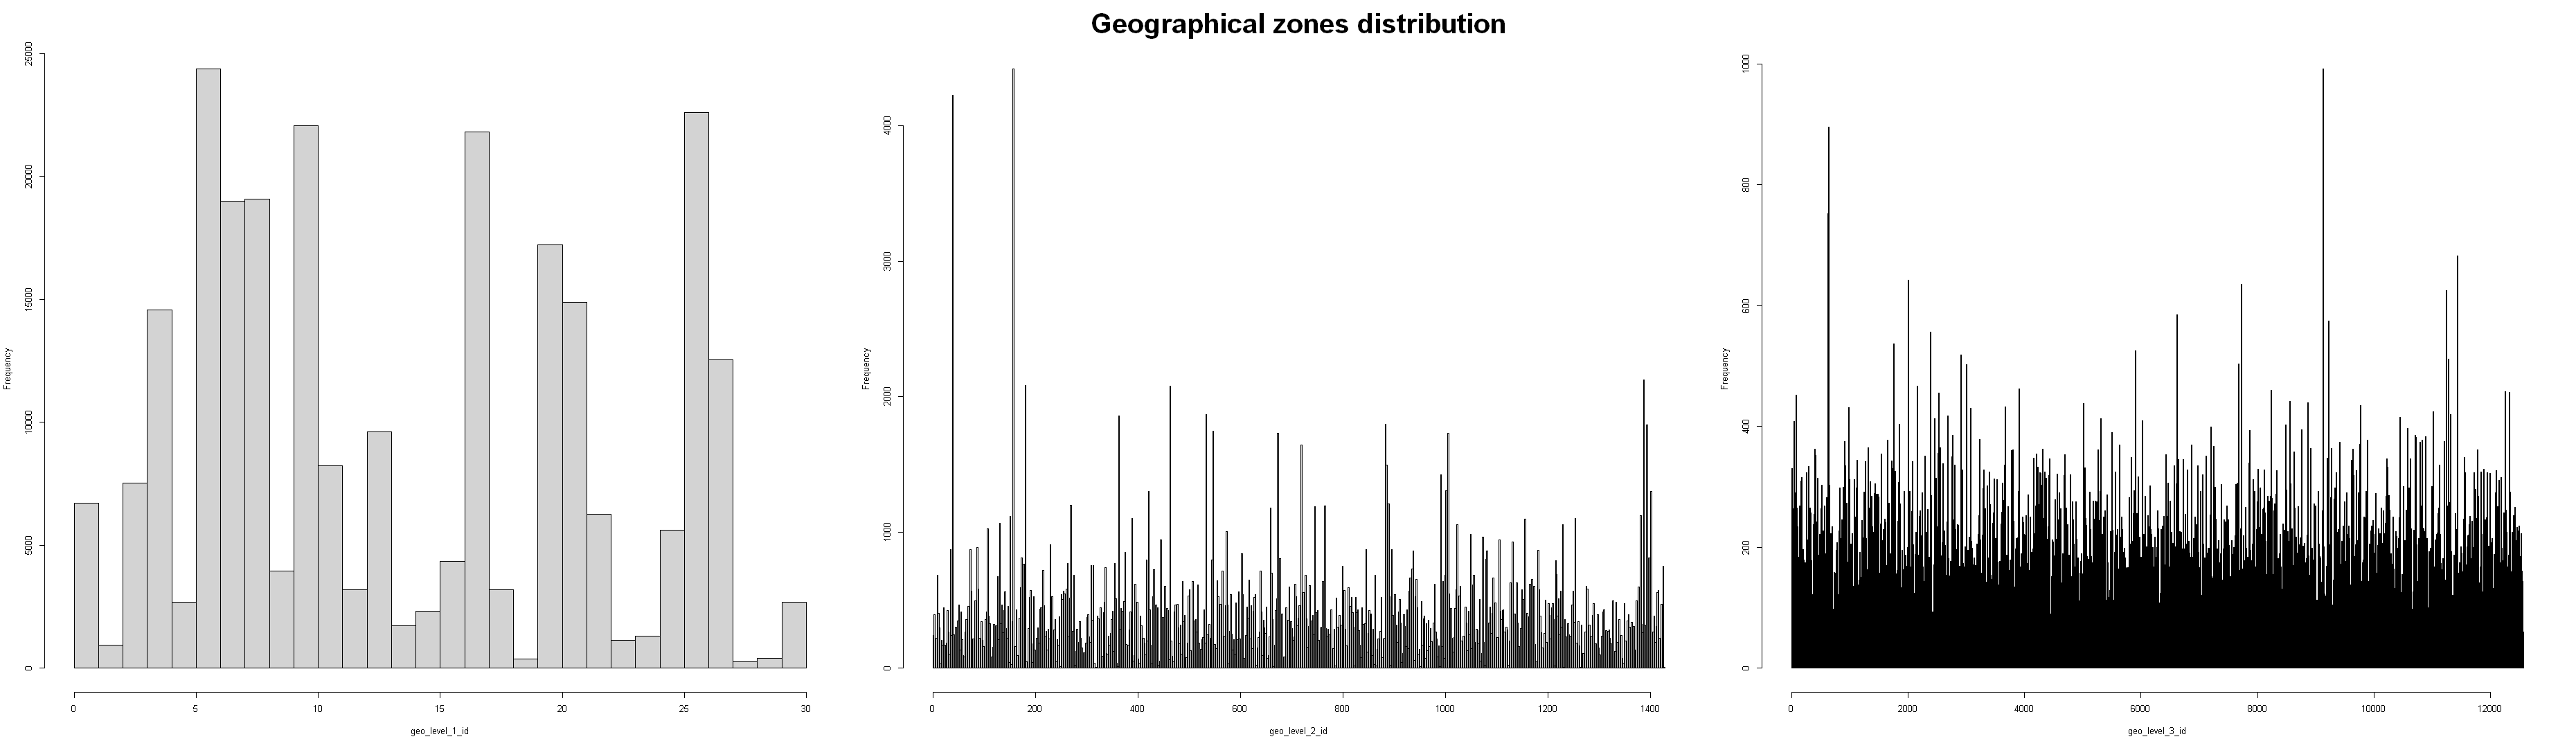

In [49]:
options(repr.plot.width=31, repr.plot.height=9)
par(mfrow=c(1,3)) 
hist(data$geo_level_1_id,xlab='geo_level_1_id',main='',breaks=30)
hist(data$geo_level_2_id,xlab='geo_level_2_id',main='Geographical zones distribution',cex.main=3,breaks=1000)
hist(data$geo_level_3_id,xlab='geo_level_3_id',main='',breaks=1000)

On dispose d'information sur les variable que l'ordinateur lui na pas. 
On vas essayer de lui les transmettre.

## Discution des package uttiliser 

In [5]:
install.packages('tictoc')

Installation du package dans 'C:/Users/Bilal/AppData/Local/R/win-library/4.2'
(car 'lib' n'est pas spécifié)



le package 'tictoc' a été décompressé et les sommes MD5 ont été vérifiées avec succés

Les packages binaires téléchargés sont dans
	C:\Users\Bilal\AppData\Local\Temp\RtmpiObIQl\downloaded_packages


In [6]:
library(ggplot2)
library(lattice)
library(caret)
library(dplyr)
library(tictoc)

Warning message:
"le package 'caret' a été compilé avec la version R 4.2.3"
Warning message:
"le package 'dplyr' a été compilé avec la version R 4.2.3"

Attachement du package : 'dplyr'


Les objets suivants sont masqués depuis 'package:stats':

    filter, lag


Les objets suivants sont masqués depuis 'package:base':

    intersect, setdiff, setequal, union


Warning message:
"le package 'tictoc' a été compilé avec la version R 4.2.3"


## Pertinance des variable et de leur type 

#### damage_grade

Les variable damage_grade que l'on cherche a predire prenne 3 valeur possible sous forme d'entier 1,2,3.
En se sens, il s'agit de variables catégoriques plutôt que de variable numérique. 
En effet, si on avait remplacer damage_grade 3 par damage_grade 10 on aurait pas changer l'information a notre disposition. 
Alors que l'ordinateur traiterait ses information différament. 
Cependnant, puisqu'il existe une structure d'ordre au sens de cette variable (i.e 1 < 2 < 3) cella peux quand même faire du sens de les traitrer comme des variable numérique. 
On pourait evisagabler de changer leur valeur tous en preservant l'odre interne comme un parametre de tunings.

#### building_id 

la variable building_id est un identifiant unique et aléatoir et ne contien pas d'information uttile pour notre problème. 

#### geo_level 

désigne les region géographic dans les quelle le batiment se situe.
Les 3 variable on une strucutre interne qui ne sont pas retranscrite dans le data set (i.e geo_level_3 inclu geo_level_2 inclue geo_level_1)
De plus, il s'agit d'entier qui n'apporte pas en temps que telle d'information. 
Si l'on echange les les indice des zone 1 et 1200 dans geo_level_3, cella ne change pas l'information a la quelle on dispose mais changera nos algorithme. 
On ne devrait pas les traiter comme variable numérique mais plutôt comme variable catégorique. 
Cependant, en pratique, elle prene un trop grand nombre de valeur différente que pour pouvoir s'en servir commme variable catégorique. 
Intuitivement, il s'aggit de variable important elle devrait donc porter une iformation importante.

#### variable catégorique 

L'information des autre varibale catégorique nous étant cacher, on se sera pas en messur d'en tirer plus d'inforamtion. 

In [58]:
length(unique(data$geo_level_3_id))

[1] 11595

In [59]:
length(unique(data$geo_level_2_id))

[1] 1414

In [60]:
length(unique(data$geo_level_1_id))

[1] 31

In [7]:
mean_damage_level_1 <- 0:30
mean_damage_level_2 <- 0:1427
mean_damage_level_3 <- 0:12567

sd_damage_level_1 <- 0:30
sd_damage_level_2 <- 0:1427
sd_damage_level_3 <- 0:12567


mean_level_1 <- data %>% group_by(geo_level_1_id) %>% 
  summarise(mean_damage=mean(damage_grade),
            .groups = 'drop')

mean_level_2 <- data %>% group_by(geo_level_2_id) %>% 
  summarise(mean_damage=mean(damage_grade),
            .groups = 'drop')

mean_level_3 <- data %>% group_by(geo_level_3_id) %>% 
  summarise(mean_damage=mean(damage_grade),
            .groups = 'drop')

sd_level_1 <- data %>% group_by(geo_level_1_id) %>% 
  summarise(sd_damage=sd(damage_grade),
            .groups = 'drop')

sd_level_2 <- data %>% group_by(geo_level_2_id) %>% 
  summarise(sd_damage=sd(damage_grade),
            .groups = 'drop')

sd_level_3 <- data %>% group_by(geo_level_3_id) %>% 
  summarise(sd_damage=sd(damage_grade),
            .groups = 'drop')


for (i in 1:31){mean_damage_level_1[i] <- mean_level_1[i,2]}  

k <- 1
for (i in 1:1428){if(i-1 == mean_level_2[k,1]){ 
        mean_damage_level_2[i] <- mean_level_2[k,2]
        k <- k+1 } else { mean_damage_level_2[i] <- NA}}

k <- 1
for (i in 1:12568){if(i-1 == mean_level_3[k,1]){ 
        mean_damage_level_3[i] <- mean_level_3[k,2]
        k <- k+1 } else { mean_damage_level_3[i] <- NA}}


for (i in 1:31){sd_damage_level_1[i] <- sd_level_1[i,2]}  

k <- 1
for (i in 1:1428){if(i-1 == sd_level_2[k,1]){ 
        sd_damage_level_2[i] <- sd_level_2[k,2]
        k <- k+1 } else { sd_damage_level_2[i] <- NA}}

k <- 1
for (i in 1:12568){if(i-1 == sd_level_3[k,1]){ 
        sd_damage_level_3[i] <- sd_level_3[k,2]
        k <- k+1 } else { sd_damage_level_3[i] <- NA}}

In [8]:
for (i in 1:nrow(data)){
    if(is.na(mean_damage_level_3[data[i,c("geo_level_3_id")]+1])){
        if(is.na(mean_damage_level_2[data[i,c("geo_level_2_id")]+1])){
            data$geo_level_3_mean_damage[i] <- as.numeric(unlist(mean_damage_level_1[data[i,c("geo_level_1_id")]+1]))
            data$geo_level_2_mean_damage[i] <- as.numeric(unlist(mean_damage_level_1[data[i,c("geo_level_1_id")]+1]))
            data$geo_level_1_mean_damage[i] <- as.numeric(unlist(mean_damage_level_1[data[i,c("geo_level_1_id")]+1]))
        } else {data$geo_level_3_mean_damage[i] <- as.numeric(unlist(mean_damage_level_2[data[i,c("geo_level_2_id")]+1]))
                data$geo_level_2_mean_damage[i] <- as.numeric(unlist(mean_damage_level_2[data[i,c("geo_level_2_id")]+1]))
                data$geo_level_1_mean_damage[i] <- as.numeric(unlist(mean_damage_level_1[data[i,c("geo_level_1_id")]+1]))}
    } else {data$geo_level_3_mean_damage[i] <- as.numeric(unlist(mean_damage_level_3[data[i,c("geo_level_3_id")]+1]))
            data$geo_level_2_mean_damage[i] <- as.numeric(unlist(mean_damage_level_2[data[i,c("geo_level_2_id")]+1]))
            data$geo_level_1_mean_damage[i] <- as.numeric(unlist(mean_damage_level_1[data[i,c("geo_level_1_id")]+1]))}
}

for (i in 1:nrow(data)){
    if(is.na(sd_damage_level_3[data[i,c("geo_level_3_id")]+1])){
        if(is.na(sd_damage_level_2[data[i,c("geo_level_2_id")]+1])){
            data$geo_level_3_sd_damage[i] <- as.numeric(unlist(sd_damage_level_1[data[i,c("geo_level_1_id")]+1]))
            data$geo_level_2_sd_damage[i] <- as.numeric(unlist(sd_damage_level_1[data[i,c("geo_level_1_id")]+1]))
            data$geo_level_1_sd_damage[i] <- as.numeric(unlist(sd_damage_level_1[data[i,c("geo_level_1_id")]+1]))
        } else {data$geo_level_3_sd_damage[i] <- as.numeric(unlist(sd_damage_level_2[data[i,c("geo_level_2_id")]+1]))
                data$geo_level_2_sd_damage[i] <- as.numeric(unlist(sd_damage_level_2[data[i,c("geo_level_2_id")]+1]))
                data$geo_level_1_sd_damage[i] <- as.numeric(unlist(sd_damage_level_1[data[i,c("geo_level_1_id")]+1]))}
    } else {data$geo_level_3_sd_damage[i] <- as.numeric(unlist(sd_damage_level_3[data[i,c("geo_level_3_id")]+1]))
            data$geo_level_2_sd_damage[i] <- as.numeric(unlist(sd_damage_level_2[data[i,c("geo_level_2_id")]+1]))
            data$geo_level_1_sd_damage[i] <- as.numeric(unlist(sd_damage_level_1[data[i,c("geo_level_1_id")]+1]))}
}

In [ ]:
for (i in 1:nrow(test)){
    if(is.na(mean_damage_level_3[test[i,c("geo_level_3_id")]+1])){
        if(is.na(mean_damage_level_2[test[i,c("geo_level_2_id")]+1])){
            test$geo_level_3_mean_damage[i] <- as.numeric(unlist(mean_damage_level_1[test[i,c("geo_level_1_id")]+1]))
            test$geo_level_2_mean_damage[i] <- as.numeric(unlist(mean_damage_level_1[test[i,c("geo_level_1_id")]+1]))
            test$geo_level_1_mean_damage[i] <- as.numeric(unlist(mean_damage_level_1[test[i,c("geo_level_1_id")]+1]))
        } else {test$geo_level_3_mean_damage[i] <- as.numeric(unlist(mean_damage_level_2[test[i,c("geo_level_2_id")]+1]))
                test$geo_level_2_mean_damage[i] <- as.numeric(unlist(mean_damage_level_2[test[i,c("geo_level_2_id")]+1]))
                test$geo_level_1_mean_damage[i] <- as.numeric(unlist(mean_damage_level_1[test[i,c("geo_level_1_id")]+1]))}
    } else {test$geo_level_3_mean_damage[i] <- as.numeric(unlist(mean_damage_level_3[test[i,c("geo_level_3_id")]+1]))
            test$geo_level_2_mean_damage[i] <- as.numeric(unlist(mean_damage_level_2[test[i,c("geo_level_2_id")]+1]))
            test$geo_level_1_mean_damage[i] <- as.numeric(unlist(mean_damage_level_1[test[i,c("geo_level_1_id")]+1]))}
}

for (i in 1:nrow(test)){
    if(is.na(sd_damage_level_3[test[i,c("geo_level_3_id")]+1])){
        if(is.na(sd_damage_level_2[test[i,c("geo_level_2_id")]+1])){
            test$geo_level_3_sd_damage[i] <- as.numeric(unlist(sd_damage_level_1[test[i,c("geo_level_1_id")]+1]))
            test$geo_level_2_sd_damage[i] <- as.numeric(unlist(sd_damage_level_1[test[i,c("geo_level_1_id")]+1]))
            test$geo_level_1_sd_damage[i] <- as.numeric(unlist(sd_damage_level_1[test[i,c("geo_level_1_id")]+1]))
        } else {test$geo_level_3_sd_damage[i] <- as.numeric(unlist(sd_damage_level_2[test[i,c("geo_level_2_id")]+1]))
                test$geo_level_2_sd_damage[i] <- as.numeric(unlist(sd_damage_level_2[test[i,c("geo_level_2_id")]+1]))
                test$geo_level_1_sd_damage[i] <- as.numeric(unlist(sd_damage_level_1[test[i,c("geo_level_1_id")]+1]))}
    } else {test$geo_level_3_sd_damage[i] <- as.numeric(unlist(sd_damage_level_3[test[i,c("geo_level_3_id")]+1]))
            test$geo_level_2_sd_damage[i] <- as.numeric(unlist(sd_damage_level_2[test[i,c("geo_level_2_id")]+1]))
            test$geo_level_1_sd_damage[i] <- as.numeric(unlist(sd_damage_level_1[test[i,c("geo_level_1_id")]+1]))}
}

In [185]:
#data <- data[,-c(1,2,3,4)]
#test <- test[,-c(1,2,3,4)]

In [13]:
data[1:3,]

,building_id,geo_level_1_id,geo_level_1_mean_damage,geo_level_1_sd_damage,geo_level_2_id,geo_level_2_mean_damage,geo_level_2_sd_damage,geo_level_3_id,geo_level_3_mean_damage,geo_level_3_sd_damage,⋯,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other,damage_grade
,<int>,<int>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,4,30,2.020477,0.4558226,266,1.984293,0.2987067,1224,1.971429,0.1690309,⋯,0,0,0,0,0,0,0,0,0,2
2,8,17,2.794480,0.4352255,409,2.977444,0.1490457,12182,3.000000,0.0000000,⋯,0,0,0,0,0,0,0,0,0,3
3,12,17,2.794480,0.4352255,716,2.984772,0.1227723,7056,3.000000,0.0000000,⋯,0,0,0,0,0,0,0,0,0,3


In [ ]:
data <- data %>% relocate(geo_level_1_mean_damage,.after=geo_level_1_id) %>% 
relocate(geo_level_2_mean_damage,.after=geo_level_2_id) %>% 
relocate(geo_level_3_mean_damage,.after=geo_level_3_id) %>% 
relocate(geo_level_1_sd_damage,.after=geo_level_1_mean_damage) %>%
relocate(geo_level_2_sd_damage,.after=geo_level_2_mean_damage) %>% 
relocate(geo_level_3_sd_damage,.after=geo_level_3_mean_damage)

In [ ]:
test <- test %>% relocate(geo_level_1_mean_damage,.after=geo_level_1_id) %>% 
relocate(geo_level_2_mean_damage,.after=geo_level_2_id) %>% 
relocate(geo_level_3_mean_damage,.after=geo_level_3_id) %>% 
relocate(geo_level_1_sd_damage,.after=geo_level_1_mean_damage) %>%
relocate(geo_level_2_sd_damage,.after=geo_level_2_mean_damage) %>% 
relocate(geo_level_3_sd_damage,.after=geo_level_3_mean_damage)

In [ ]:
write.csv(data, file = "data_target_encoding.csv", row.names = FALSE)
write.csv(test, file = "test_target_encoding.csv", row.names = FALSE)

In [36]:
summary(data)

  building_id      geo_level_1_id geo_level_1_mean_damage geo_level_1_sd_damage
 Min.   :      4   Min.   : 0.0   Min.   :1.731           Min.   :0.3359       
 1st Qu.: 261265   1st Qu.: 7.0   1st Qu.:2.026           1st Qu.:0.5103       
 Median : 525836   Median :12.0   Median :2.172           Median :0.5554       
 Mean   : 525715   Mean   :13.9   Mean   :2.239           Mean   :0.5377       
 3rd Qu.: 789792   3rd Qu.:21.0   3rd Qu.:2.446           3rd Qu.:0.5669       
 Max.   :1052934   Max.   :30.0   Max.   :2.794           Max.   :0.6070       
                                                                               
 geo_level_2_id   geo_level_2_mean_damage geo_level_2_sd_damage geo_level_3_id 
 Min.   :   0.0   Min.   :1.000           Min.   :0.0000        Min.   :    0  
 1st Qu.: 350.0   1st Qu.:2.018           1st Qu.:0.4205        1st Qu.: 3073  
 Median : 702.0   Median :2.212           Median :0.4993        Median : 6272  
 Mean   : 700.9   Mean   :2.239         

In [1]:
data <- read.csv("data_target_encoding.csv",stringsAsFactors = T)
test <- read.csv("test_target_encoding.csv",stringsAsFactors = T)

We remove age outliers for better normalization

In [ ]:
data<-filter(data,age<995)

In [ ]:
library(recipes)

Le chargement a nécessité le package : dplyr


Attachement du package : 'dplyr'


Les objets suivants sont masqués depuis 'package:stats':

    filter, lag


Les objets suivants sont masqués depuis 'package:base':

    intersect, setdiff, setequal, union



Attachement du package : 'recipes'


L'objet suivant est masqué depuis 'package:stats':

    step




In [11]:
dataNN <- recipe(damage_grade ~ ., data) %>%
  step_normalize(count_floors_pre_eq, age, area_percentage, height_percentage, geo_level_1_mean_damage, geo_level_2_mean_damage, geo_level_3_mean_damage, geo_level_1_sd_damage,geo_level_2_sd_damage,geo_level_3_sd_damage) %>%
  step_num2factor(damage_grade,levels=c('1','2','3')) %>%
  step_dummy(all_nominal(), one_hot = TRUE) %>%
  step_rm(geo_level_1_id,geo_level_2_id,geo_level_3_id,building_id) %>%
  prep(log_changes=TRUE) %>%
  bake(new_data = NULL)

step_normalize (normalize_L3TaL): same number of columns

step_num2factor (num2factor_PyRvN): same number of columns

step_dummy (dummy_sW3FA): 
 new (41): land_surface_condition_n, land_surface_condition_o, ...
 removed (9): land_surface_condition, foundation_type, roof_type, ...

step_rm (rm_0UBxX): 
 removed (4): building_id, geo_level_1_id, geo_level_2_id, ...



In [4]:
testNN <- recipe( ~ ., test) %>%
  step_normalize(count_floors_pre_eq, age, area_percentage, height_percentage, geo_level_1_mean_damage, geo_level_2_mean_damage, geo_level_3_mean_damage, geo_level_1_sd_damage,geo_level_2_sd_damage,geo_level_3_sd_damage) %>%
  step_dummy(all_nominal(), one_hot = TRUE) %>%
  step_rm(geo_level_1_id,geo_level_2_id,geo_level_3_id) %>%
  prep(log_changes=TRUE) %>%
  bake(new_data = NULL)

step_normalize (normalize_6hRDd): same number of columns

step_dummy (dummy_116kF): 
 new (38): land_surface_condition_n, land_surface_condition_o, ...
 removed (8): land_surface_condition, foundation_type, roof_type, ...

step_rm (rm_c5QAd): 
 removed (3): geo_level_1_id, geo_level_2_id, geo_level_3_id



In [19]:
write.csv(dataNN, file = "dataNN_target_encoding.csv", row.names = FALSE)


In [5]:
write.csv(testNN, file = "testNN_target_encoding.csv", row.names = FALSE)

In [182]:
#data[c("damage_grade")] <- lapply(data[c("damage_grade")], function(x) as.factor(x))
nzv <- nearZeroVar(data)
data <- data[, -nzv]
test <- test[, -nzv]

In [173]:
dim(data)

[1] 260601     21

In [174]:
data[1:2,]

,count_floors_pre_eq,age,area_percentage,height_percentage,land_surface_condition,foundation_type,roof_type,ground_floor_type,other_floor_type,position,⋯,has_superstructure_mud_mortar_stone,has_superstructure_mud_mortar_brick,has_superstructure_cement_mortar_brick,has_superstructure_timber,has_superstructure_bamboo,count_families,has_secondary_use,has_secondary_use_agriculture,damage_grade,geo_level_damage
,<int>,<int>,<int>,<int>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<fct>,<dbl>
1,1,25,5,2,t,r,n,f,j,s,⋯,1,0,0,0,0,0,0,0,2,1.971429
2,2,0,13,7,t,r,n,f,q,s,⋯,1,0,0,0,0,1,0,0,3,3.000000


In [18]:
cor(dataNN)

,geo_level_1_mean_damage,geo_level_1_sd_damage,geo_level_2_mean_damage,geo_level_2_sd_damage,geo_level_3_mean_damage,geo_level_3_sd_damage,count_floors_pre_eq,age,area_percentage,height_percentage,⋯,plan_configuration_q,plan_configuration_s,plan_configuration_u,legal_ownership_status_a,legal_ownership_status_r,legal_ownership_status_v,legal_ownership_status_w,damage_grade_X1,damage_grade_X2,damage_grade_X3
geo_level_1_mean_damage,1.0000000000,-0.430237603,0.803404284,-0.1980410410,0.720427907,-0.135779899,0.274421291,0.101362552,-0.0346302210,0.175881895,⋯,0.0342334457,-1.262912e-02,-0.0356015458,-0.130828391,0.0046719684,0.0596078996,0.0715558061,-0.27344553,-0.254480716,0.437883305
geo_level_1_sd_damage,-0.4302376033,1.000000000,-0.345600885,0.4245352422,-0.309866321,0.294486541,-0.084497814,-0.023001692,0.0266107997,-0.010451490,⋯,0.0009237050,4.816228e-03,0.0270138204,0.081616721,0.0050630888,-0.0495399939,-0.0274181003,0.16573525,0.052225228,-0.158357202
geo_level_2_mean_damage,0.8034042835,-0.345600885,1.000000000,-0.3210269846,0.896531733,-0.220224481,0.202220976,0.078011858,-0.0621973181,0.129569373,⋯,0.0207493567,-1.214294e-02,-0.0570335751,-0.136638827,-0.0083571166,0.0809983667,0.0494479857,-0.36611722,-0.286100478,0.528966462
geo_level_2_sd_damage,-0.1980410410,0.424535242,-0.321026985,1.0000000000,-0.287850565,0.630525044,0.002054150,-0.020673553,0.0713419074,0.041359515,⋯,0.0084481707,5.344663e-03,0.0376754487,0.084106346,0.0287745813,-0.0858069142,0.0193682708,0.24091394,-0.054900667,-0.092925700
geo_level_3_mean_damage,0.7204279073,-0.309866321,0.896531733,-0.2878505649,1.000000000,-0.235151563,0.169368340,0.067184917,-0.0776495636,0.102062789,⋯,0.0214047940,-1.047417e-02,-0.0571790180,-0.125333990,-0.0089752253,0.0754626786,0.0441459549,-0.41918427,-0.306290528,0.583310021
geo_level_3_sd_damage,-0.1357798991,0.294486541,-0.220224481,0.6305250444,-0.235151563,1.000000000,-0.006256986,-0.036462366,0.0710253746,0.027736589,⋯,0.0027020562,6.283827e-03,0.0284383004,0.060125753,0.0280824021,-0.0737814170,0.0315753040,0.22939394,-0.083331981,-0.055894882
count_floors_pre_eq,0.2744212914,-0.084497814,0.202220976,0.0020541497,0.169368340,-0.006256986,1.000000000,0.298722839,0.1009787867,0.772625134,⋯,-0.0333795102,-3.275653e-03,-0.0052640103,-0.096704907,-0.0082513305,0.0732057352,0.0069699077,-0.12981601,0.002755254,0.078223026
age,0.1013625523,-0.023001692,0.078011858,-0.0206735525,0.067184917,-0.036462366,0.298722839,1.000000000,-0.0278064572,0.204744747,⋯,-0.0137221225,-4.629428e-03,-0.0096725624,-0.081693013,0.0007651493,0.0532890595,0.0161648648,-0.18368573,0.035466248,0.077559624
area_percentage,-0.0346302210,0.026610800,-0.062197318,0.0713419074,-0.077649564,0.071025375,0.100978787,-0.027806457,1.0000000000,0.196876546,⋯,0.0165913988,1.920138e-02,0.0960736019,-0.028239796,-0.0152858488,0.0294188779,-0.0034594698,0.12608349,0.004064901,-0.083047124
height_percentage,0.1758818952,-0.010451490,0.129569373,0.0413595154,0.102062789,0.027736589,0.772625134,0.204744747,0.1968765462,1.000000000,⋯,-0.0167580818,-5.968625e-05,0.0059894741,-0.078740332,-0.0088688954,0.0630567644,0.0008076396,-0.04878420,-0.001735055,0.032302839
